In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

# Read data

In [3]:
vanilla = pd.read_csv('compas-mpa-cat-wout-agg-vanilla_lr-100.csv', index_col=0)
zhang = pd.read_csv('compas-mpa-cat-wout-agg-mult_adv-100.csv', index_col=0)

In [4]:
vanilla

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a2_dp,a2_deqodds,a2_deqopp,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.7917,0.7917,0.6989,0.9117,0.9193,0.8737,0.3069,0.6535,0.3069,0.6608,0.5000,0.0000
1,SkVanillaLR,29,0.7838,0.7838,0.6891,0.8881,0.8684,0.7840,0.3741,0.6130,0.3741,0.6000,0.4375,0.0000
2,SkVanillaLR,42,0.7834,0.7834,0.6868,0.8903,0.8861,0.8159,0.3129,0.4289,0.3129,0.6620,0.5000,0.0000
3,SkVanillaLR,55,0.7880,0.7880,0.6993,0.8715,0.8513,0.7561,0.4894,0.5911,0.4894,0.2500,0.5000,0.0000
4,SkVanillaLR,73,0.7880,0.7880,0.6903,0.9045,0.9136,0.8772,0.3159,0.6163,0.3159,0.6478,0.5000,0.0000


In [5]:
zhang

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a2_dp,a2_deqodds,a2_deqopp,wc_spd,wc_aod,wc_eod,last_cosine_similarity
0,MultAdvBin4DP,13,0.7614,0.7614,0.6838,0.9795,0.9851,0.9838,0.6923,0.7836,0.6923,0.2500,0.1667,0.0000,-0.1696
1,MultAdvBin4DP,29,0.7585,0.7585,0.6734,0.9935,0.9810,0.9770,0.9679,0.9385,0.9679,0.0000,0.0000,0.0000,-0.1131
2,MultAdvBin4DP,42,0.7727,0.7727,0.6914,0.9488,0.9525,0.9340,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,-0.2505
3,MultAdvBin4DP,55,0.7509,0.7509,0.6649,0.9921,0.9514,0.9460,0.5902,0.7796,0.5902,0.2500,0.5000,0.0000,-0.2219
4,MultAdvBin4DP,73,0.7718,0.7718,0.6851,0.9401,0.9655,0.9562,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,-0.0849
5,MultAdvBin4EqOdds,13,0.7689,0.7689,0.6915,0.9867,0.9711,0.9603,0.7397,0.8074,0.7397,0.2500,0.1667,0.0000,-0.1473
6,MultAdvBin4EqOdds,29,0.7765,0.7765,0.6929,0.9792,0.9937,0.9951,0.9889,0.9490,0.9889,0.0000,0.0000,0.0000,-0.0288
7,MultAdvBin4EqOdds,42,0.7770,0.7770,0.6934,0.9630,0.9553,0.9241,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,-0.0750
8,MultAdvBin4EqOdds,55,0.7609,0.7609,0.6752,0.9859,0.9681,0.9673,0.5902,0.7653,0.5902,0.2500,0.5000,0.0000,-0.1940
9,MultAdvBin4EqOdds,73,0.7827,0.7827,0.6922,0.9278,0.9522,0.9404,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,-0.1104


In [6]:
zhang[["model_name", "cv_seed", "last_cosine_similarity"]]

,model_name,cv_seed,last_cosine_similarity
0,MultAdvBin4DP,13,-0.1696
1,MultAdvBin4DP,29,-0.1131
2,MultAdvBin4DP,42,-0.2505
3,MultAdvBin4DP,55,-0.2219
4,MultAdvBin4DP,73,-0.0849
5,MultAdvBin4EqOdds,13,-0.1473
6,MultAdvBin4EqOdds,29,-0.0288
7,MultAdvBin4EqOdds,42,-0.0750
8,MultAdvBin4EqOdds,55,-0.1940
9,MultAdvBin4EqOdds,73,-0.1104


# Predictive performance

## Acc mean and std

In [6]:
vanilla_acc = vanilla.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([vanilla_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,SkVanillaLR,0.7870,0.0034
1,MultAdvBin4DP,0.7631,0.0092
2,MultAdvBin4EqOdds,0.7732,0.0084
3,MultAdvBin4EqOpp,0.7458,0.0044


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['SkVanillaLR', 'MultAdvBin4DP', 'MultAdvBin4EqOdds', 'MultAdvBin4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,SkVanillaLR,0.7870,0.0034
1,MultAdvBin4DP,0.7631,0.0092
2,MultAdvBin4EqOdds,0.7732,0.0084
3,MultAdvBin4EqOpp,0.7458,0.0044


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

 0.787 $\pm$ 0.0034
0.7631 $\pm$ 0.0092
0.7732 $\pm$ 0.0084
0.7458 $\pm$ 0.0044


## Micro-f1 mean and std

In [11]:
vanilla_micro = vanilla.groupby(['model_name'])['f1-micro'].agg([mean, stdev])
zhang_micro = zhang.groupby(['model_name'])['f1-micro'].agg([mean, stdev])

In [12]:
micro = pd.concat([vanilla_micro, zhang_micro])
micro = micro.reset_index()
micro = micro.rename(columns={'index': 'model_name'})
micro

,model_name,mean,stdev
0,SkVanillaLR,0.7870,0.0034
1,MultAdvBin4DP,0.7631,0.0092
2,MultAdvBin4EqOdds,0.7732,0.0084
3,MultAdvBin4EqOpp,0.7458,0.0044


In [13]:
micro['model_name'] = names
micro

,model_name,mean,stdev
0,SkVanillaLR,0.7870,0.0034
1,MultAdvBin4DP,0.7631,0.0092
2,MultAdvBin4EqOdds,0.7732,0.0084
3,MultAdvBin4EqOpp,0.7458,0.0044


In [14]:
print((micro['mean'].round(4).astype(str) + ' $\pm$ ' + micro['stdev'].round(4).astype(str)).to_string(index=False))

 0.787 $\pm$ 0.0034
0.7631 $\pm$ 0.0092
0.7732 $\pm$ 0.0084
0.7458 $\pm$ 0.0044


## Macro-f1 mean and std

In [15]:
vanilla_macro = vanilla.groupby(['model_name'])['f1-macro'].agg([mean, stdev])
zhang_macro = zhang.groupby(['model_name'])['f1-macro'].agg([mean, stdev])

In [16]:
macro = pd.concat([vanilla_macro, zhang_macro])
macro = macro.reset_index()
macro = macro.rename(columns={'index': 'model_name'})
macro

,model_name,mean,stdev
0,SkVanillaLR,0.6929,0.0058
1,MultAdvBin4DP,0.6798,0.0105
2,MultAdvBin4EqOdds,0.6890,0.0078
3,MultAdvBin4EqOpp,0.6608,0.0060


In [17]:
macro['model_name'] = names
macro

,model_name,mean,stdev
0,SkVanillaLR,0.6929,0.0058
1,MultAdvBin4DP,0.6798,0.0105
2,MultAdvBin4EqOdds,0.6890,0.0078
3,MultAdvBin4EqOpp,0.6608,0.0060


In [18]:
print((macro['mean'].round(4).astype(str) + ' $\pm$ ' + macro['stdev'].round(4).astype(str)).to_string(index=False))

0.6929 $\pm$ 0.0058
0.6798 $\pm$ 0.0105
 0.689 $\pm$ 0.0078
 0.6608 $\pm$ 0.006


# Group fairness for first protected attribute

## DP mean and std

In [19]:
vanilla_dp = vanilla.groupby(['model_name'])['a1_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a1_dp'].agg([mean, stdev])

In [20]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.8932,0.0156
1,MultAdvBin4DP,0.9708,0.0248
2,MultAdvBin4EqOdds,0.9685,0.0247
3,MultAdvBin4EqOpp,0.8766,0.0282


In [21]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8932 $\pm$ 0.0156
0.9708 $\pm$ 0.0248
0.9685 $\pm$ 0.0247
0.8766 $\pm$ 0.0282


## DEqOdds mean and std

In [22]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])

In [23]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.8877,0.0290
1,MultAdvBin4DP,0.9671,0.0156
2,MultAdvBin4EqOdds,0.9681,0.0164
3,MultAdvBin4EqOpp,0.8769,0.0276


In [24]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

 0.8877 $\pm$ 0.029
0.9671 $\pm$ 0.0156
0.9681 $\pm$ 0.0164
0.8769 $\pm$ 0.0276


## DEqOpp mean and std

In [25]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])

In [26]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.8214,0.0537
1,MultAdvBin4DP,0.9594,0.0209
2,MultAdvBin4EqOdds,0.9574,0.0271
3,MultAdvBin4EqOpp,0.8290,0.0369


In [27]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.8214 $\pm$ 0.0537
0.9594 $\pm$ 0.0209
0.9574 $\pm$ 0.0271
 0.829 $\pm$ 0.0369


# Group fairness for second protected attribute

## DP mean and std

In [28]:
vanilla_dp = vanilla.groupby(['model_name'])['a2_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a2_dp'].agg([mean, stdev])

In [29]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.3599,0.0773
1,MultAdvBin4DP,0.8501,0.1945
2,MultAdvBin4EqOdds,0.8638,0.1891
3,MultAdvBin4EqOpp,0.4807,0.1728


In [30]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.3599 $\pm$ 0.0773
0.8501 $\pm$ 0.1945
0.8638 $\pm$ 0.1891
0.4807 $\pm$ 0.1728


## DEqOdds mean and std

In [31]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])

In [32]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.5805,0.0877
1,MultAdvBin4DP,0.9004,0.1113
2,MultAdvBin4EqOdds,0.9043,0.1107
3,MultAdvBin4EqOpp,0.6304,0.1646


In [33]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.5805 $\pm$ 0.0877
0.9004 $\pm$ 0.1113
0.9043 $\pm$ 0.1107
0.6304 $\pm$ 0.1646


## DEqOpp mean and std

In [34]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])

In [35]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.3599,0.0773
1,MultAdvBin4DP,0.8501,0.1945
2,MultAdvBin4EqOdds,0.8638,0.1891
3,MultAdvBin4EqOpp,0.4807,0.1728


In [36]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.3599 $\pm$ 0.0773
0.8501 $\pm$ 0.1945
0.8638 $\pm$ 0.1891
0.4807 $\pm$ 0.1728


# Intersectional Fairness

## WCSPD mean and std

In [37]:
vanilla_wcspd = vanilla.groupby(['model_name'])['wc_spd'].agg([mean, stdev])
zhang_wcspd = zhang.groupby(['model_name'])['wc_spd'].agg([mean, stdev])

In [38]:
wcspd = pd.concat([vanilla_wcspd, zhang_wcspd])
wcspd = wcspd.reset_index()
wcspd = wcspd.rename(columns={'index': 'model_name'})
wcspd['model_name'] = names
wcspd

,model_name,mean,stdev
0,SkVanillaLR,0.5641,0.1774
1,MultAdvBin4DP,0.1000,0.1369
2,MultAdvBin4EqOdds,0.1000,0.1369
3,MultAdvBin4EqOpp,0.4446,0.1836


In [39]:
print((wcspd['mean'].round(4).astype(str) + ' $\pm$ ' + wcspd['stdev'].round(4).astype(str)).to_string(index=False))

0.5641 $\pm$ 0.1774
   0.1 $\pm$ 0.1369
   0.1 $\pm$ 0.1369
0.4446 $\pm$ 0.1836


## WCAOD mean and std

In [40]:
vanilla_wcaod = vanilla.groupby(['model_name'])['wc_aod'].agg([mean, stdev])
zhang_wcaod = zhang.groupby(['model_name'])['wc_aod'].agg([mean, stdev])

In [41]:
wcaod = pd.concat([vanilla_wcaod, zhang_wcaod])
wcaod = wcaod.reset_index()
wcaod = wcaod.rename(columns={'index': 'model_name'})
wcaod['model_name'] = names
wcaod

,model_name,mean,stdev
0,SkVanillaLR,0.4875,0.0280
1,MultAdvBin4DP,0.1333,0.2173
2,MultAdvBin4EqOdds,0.1333,0.2173
3,MultAdvBin4EqOpp,0.4305,0.1476


In [42]:
print((wcaod['mean'].round(4).astype(str) + ' $\pm$ ' + wcaod['stdev'].round(4).astype(str)).to_string(index=False))

 0.4875 $\pm$ 0.028
0.1333 $\pm$ 0.2173
0.1333 $\pm$ 0.2173
0.4305 $\pm$ 0.1476


## WCEOD mean and std

In [43]:
vanilla_wceod = vanilla.groupby(['model_name'])['wc_eod'].agg([mean, stdev])
zhang_wceod = zhang.groupby(['model_name'])['wc_eod'].agg([mean, stdev])

In [44]:
wceod = pd.concat([vanilla_wceod, zhang_wceod])
wceod = wceod.reset_index()
wceod = wceod.rename(columns={'index': 'model_name'})
wceod['model_name'] = names
wceod

,model_name,mean,stdev
0,SkVanillaLR,0.0000,0.0000
1,MultAdvBin4DP,0.0000,0.0000
2,MultAdvBin4EqOdds,0.0000,0.0000
3,MultAdvBin4EqOpp,0.0000,0.0000


In [45]:
print((wceod['mean'].round(4).astype(str) + ' $\pm$ ' + wceod['stdev'].round(4).astype(str)).to_string(index=False))

0.0 $\pm$ 0.0
0.0 $\pm$ 0.0
0.0 $\pm$ 0.0
0.0 $\pm$ 0.0


# T-test

In [46]:
vanilla_lr = vanilla
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [47]:
models = [
    vanilla_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [48]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [49]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

## for accuracies

In [50]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [51]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0073,-,-,-
MultAdvBin4EqOdds,0.0405,0.0112,-,-
MultAdvBin4EqOpp,0.0001,0.0022,0.0007,-


In [52]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-micro'], models[j]['f1-micro'])
        res_acc.iloc[i, j] = stat[1]

In [53]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0073,-,-,-
MultAdvBin4EqOdds,0.0405,0.0112,-,-
MultAdvBin4EqOpp,0.0001,0.0022,0.0007,-


In [54]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-macro'], models[j]['f1-macro'])
        res_acc.iloc[i, j] = stat[1]

In [55]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.1123,-,-,-
MultAdvBin4EqOdds,0.5282,0.0323,-,-
MultAdvBin4EqOpp,0.0007,0.0092,0.0011,-


## for group fairness A1

In [56]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_dp'], models[j]['a1_dp'])
        res_dp.iloc[i, j] = stat[1]

In [57]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0075,-,-,-
MultAdvBin4EqOdds,0.0073,0.7034,-,-
MultAdvBin4EqOpp,0.3220,0.0003,0.0017,-


In [58]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqodds'], models[j]['a1_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [59]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0023,,,
MultAdvBin4EqOdds,0.0098,0.8873,,
MultAdvBin4EqOpp,0.5801,0.0003,0.0002,


In [60]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqopp'], models[j]['a1_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [61]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0037,,,
MultAdvBin4EqOdds,0.0124,0.8396,,
MultAdvBin4EqOpp,0.7839,0.0002,0.0005,


## for group fairness A2

In [62]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_dp'], models[j]['a2_dp'])
        res_dp.iloc[i, j] = stat[1]

In [63]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0118,-,-,-
MultAdvBin4EqOdds,0.0105,0.2177,-,-
MultAdvBin4EqOpp,0.1931,0.0815,0.0689,-


In [64]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqodds'], models[j]['a2_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [65]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0146,,,
MultAdvBin4EqOdds,0.0132,0.5620,,
MultAdvBin4EqOpp,0.3995,0.0810,0.0772,


In [66]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqopp'], models[j]['a2_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [67]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0118,,,
MultAdvBin4EqOdds,0.0105,0.2177,,
MultAdvBin4EqOpp,0.1931,0.0815,0.0689,


## for intersectional fairness

In [68]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_spd'], models[j]['wc_spd'])
        res_dp.iloc[i, j] = stat[1]

In [69]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0203,-,-,-
MultAdvBin4EqOdds,0.0203,-,-,-
MultAdvBin4EqOpp,0.1988,0.0725,0.0725,-


In [70]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_aod'], models[j]['wc_aod'])
        res_deqodds.iloc[i, j] = stat[1]

In [71]:
res_deqodds.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0194,-,-,-
MultAdvBin4EqOdds,0.0194,-,-,-
MultAdvBin4EqOpp,0.4630,0.0705,0.0705,-


In [72]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_eod'], models[j]['wc_eod'])
        res_deqopp.iloc[i, j] = stat[1]

In [73]:
res_deqopp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,-,-,-,-
MultAdvBin4EqOdds,-,-,-,-
MultAdvBin4EqOpp,-,-,-,-


# Plotting

## Plotting Accuracies

In [74]:
model_names = vanilla['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [75]:
model_names

['SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp']

In [76]:
model_accs = vanilla['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26037/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


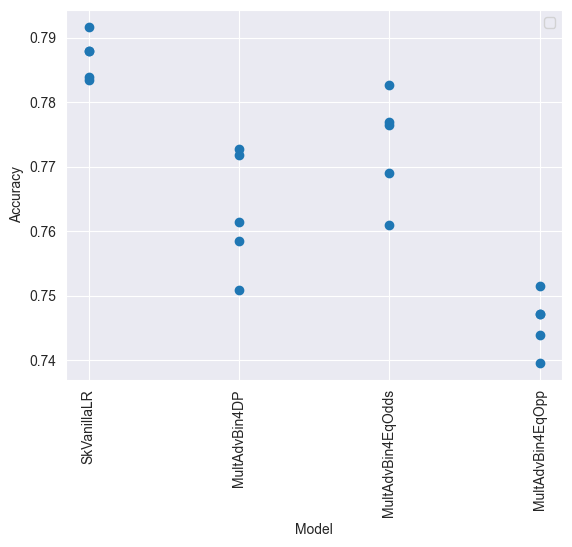

In [77]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [78]:
model_spd = vanilla['wc_spd'].to_list()+zhang['wc_spd'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26037/545090117.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


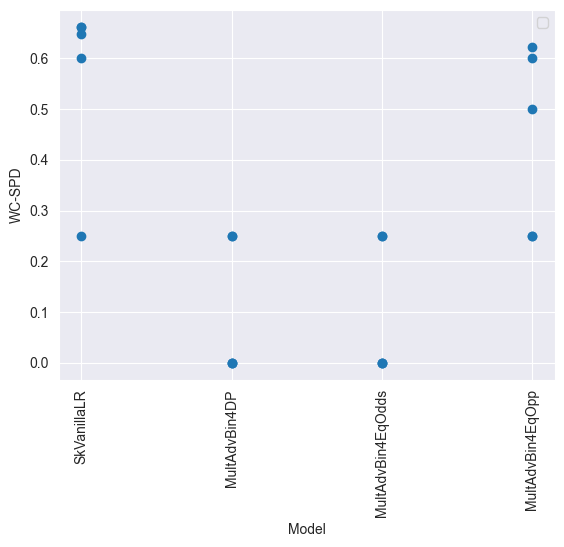

In [79]:
plt.plot()
plt.ylabel('WC-SPD')

plt.scatter(model_names, model_spd)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26037/1727290324.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


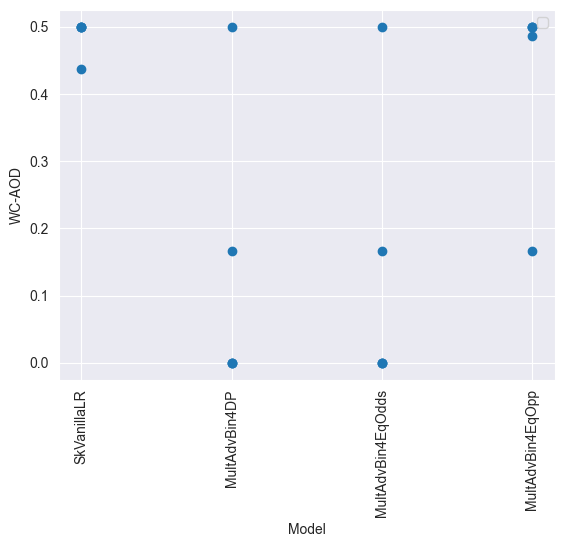

In [80]:
model_aod = vanilla['wc_aod'].to_list()+zhang['wc_aod'].to_list()
plt.plot()
plt.ylabel('WC-AOD')

plt.scatter(model_names, model_aod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26037/2617305754.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


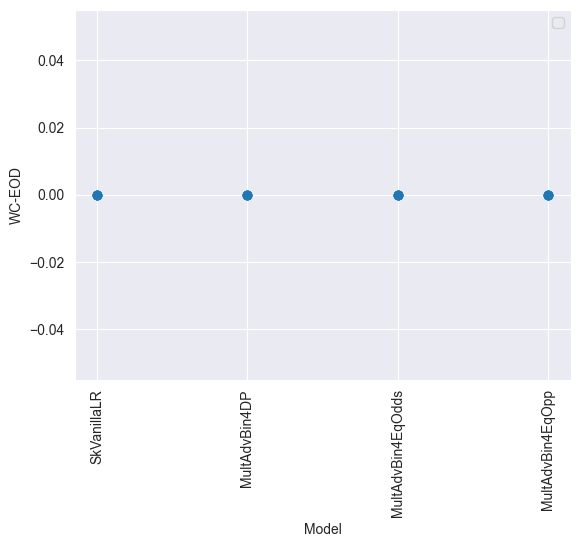

In [81]:
model_eod = vanilla['wc_eod'].to_list()+zhang['wc_eod'].to_list()
plt.plot()
plt.ylabel('WC-EOD')

plt.scatter(model_names, model_eod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x WC-SPD

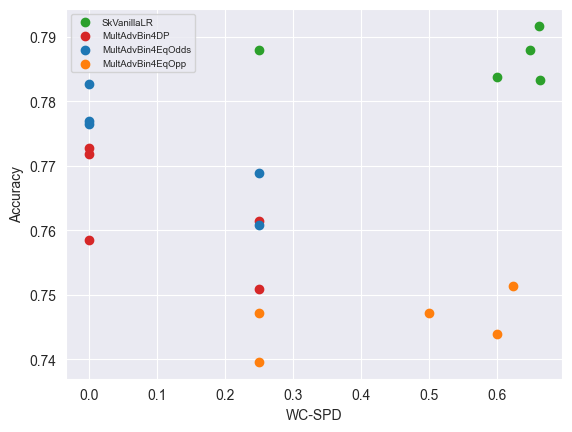

<Figure size 700x700 with 0 Axes>

In [82]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-SPD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_spd[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-AOD

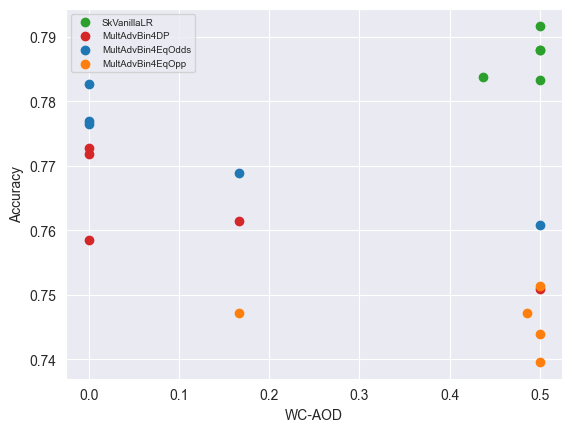

<Figure size 700x700 with 0 Axes>

In [83]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-AOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_aod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-EOD

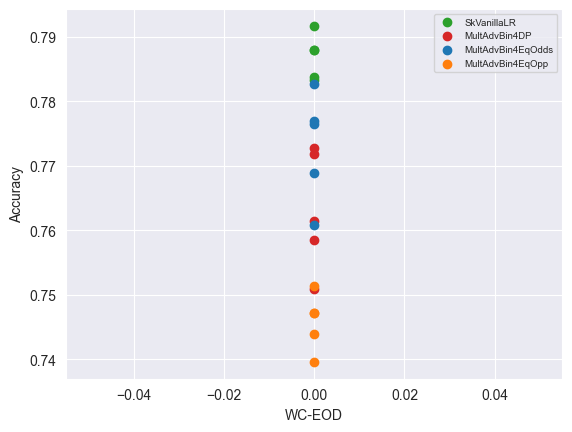

<Figure size 700x700 with 0 Axes>

In [84]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-EOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_eod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()